# DeepSeek: детекция экономических нарративов по новостям (из Excel)

Этот ноутбук читает новости из Excel-файла и по каждой записи вызывает модель **DeepSeek** (OpenAI-совместимый API),
чтобы определить:

1) является ли новость потенциальным экономическим нарративом (**Да/Нет**),
2) почему модель так считает (краткое развёрнутое объяснение).

В процессе создаются промежуточные CSV (**latest.csv** + исторические чекпоинты в подпапке),
а по завершении сохраняется итоговый Excel с вкладками **results** и **summary**.

👉 Файл по умолчанию: `/mnt/data/60_topic.xlsx` (можете поменять в конфигурации).

In [2]:
# Установка зависимостей (если нужно)
# !pip -q install pandas openai python-dotenv xlsxwriter

In [3]:
import os
import re
import json
import time
import uuid
import pandas as pd
import datetime as dt
from typing import Dict, Any, List, Optional
from dotenv import load_dotenv

load_dotenv()

True

In [27]:
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY", "")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL", "https://api.deepseek.com/v1")
DEEPSEEK_MODEL = os.getenv("DEEPSEEK_MODEL", "deepseek-chat")

INPUT_XLSX = "60_topic.xlsx"
SHEET_NAME = 0
TEXT_COLUMN = "message"
ID_COLUMN = "id"
# TITLE_COLUMN = "title"
# DATE_COLUMN = "date"

OUTDIR = "runs/xlsx_run"
SAVE_EVERY = 20
BATCH_SIZE = 1
RESUME = False
SLEEP_BETWEEN = 0.0
TEMPERATURE = 0.2
MAX_TOKENS = 800

assert DEEPSEEK_API_KEY, "Не найден DEEPSEEK_API_KEY в окружении/.env — задайте переменную или создайте .env"

In [28]:
PROMPT_TEMPLATE = r'''
Проанализируй следующий текст новости:

"{text}"

Используя следующие критерии, определи, является ли эта новость потенциальным экономическим нарративом:

1. Триггерное событие 
   - Есть ли в новости чёткое событие или факт, с которого начинается тема?
   - Насколько это событие способно привлечь массовое внимание или вызвать тревогу?

2. Причинно-следственные связи
   - Пытается ли автор текста объяснить, как одно экономическое явление приводит к другому?
   - Насколько логична и структурирована эта цепочка (даже если она упрощена)?

3. Эмоциональная окраска и тревожность
   - Используются ли слова или фразы, передающие тревожность, страх или срочность?
   - Возникает ли ощущение кризиса, неотложности или неопределённости?

4. Роль государства и институтов
   - Упоминаются ли органы государственной власти или регулирующие структуры (ЦБ, правительство, министерства)?
   - Представлена ли их политика или меры как возможная угроза или решение кризиса?

5. Участие СМИ и лидеров мнений
   - Ссылается ли автор на заявления экспертов, аналитиков, политиков или блогеров?
   - Упоминается ли массовое освещение в прессе, соцсетях?

6. Простая, понятная логика (даже если неполная или упрощённая)
   - Сводится ли суть новости к нескольким чётким "причинам" и "следствиям"?
   - Есть ли в тексте обобщающие фразы ("кризис неизбежен", "все будут страдать")?

7. Самоусиливающийся эффект (эффект "снежного кома")
   - Видны ли намёки на то, что эта новость может породить новые волны паники, ажиотажа или дополнительных комментариев?
   - Рассказывают ли источники о будущих событиях, которые могут усугубить ситуацию?

### Задача
1. Опиши, какие из перечисленных критериев присутствуют в тексте и приведи краткие примеры из новости (если есть).
2. Сформулируй вывод:
   - "Да, потенциально экономический нарратив" — если присутствует большинство критериев.
   - "Нет, скорее всего нет" — если большинство критериев не выявлено или они слабо выражены.

Ответ верни строго в формате JSON со следующими полями:
{
  "is_narrative": "Да" | "Нет",
  "reasoning": "<развёрнутое объяснение с краткими примерами по критериям>"
}
Если не можешь уверенно определить, всё равно вынеси бинарное решение в поле "is_narrative".
'''

SYSTEM_INSTRUCTION = (
    "Ты — аналитик экономических нарративов. "
    "Отвечай строго в формате JSON (без дополнительного текста до и после)."
)

In [29]:
def now_ts() -> str:
    return dt.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)

def read_input_excel(path: str, sheet, text_col: str, id_col: str):
    df = pd.read_excel(path, sheet_name=sheet)
    if text_col not in df.columns:
        raise ValueError(f"Входной Excel должен содержать столбец '{text_col}'. Доступные: {list(df.columns)}")
    for col in [id_col,]:
        if col not in df.columns:
            df[col] = None
    if df[id_col].isna().all() or df[id_col].astype(str).eq('').all():
        df[id_col] = [str(uuid.uuid4()) for _ in range(len(df))]
    out = pd.DataFrame({
        'id': df[id_col].astype(str),
        'text': df[text_col].astype(str)
    })
    return out

def sanitize_json(s: str) -> str:
    s = str(s).strip()
    start = s.find('{')
    end = s.rfind('}')
    if start != -1 and end != -1 and end > start:
        return s[start:end+1]
    return s

def coerce_result(obj: Dict[str, Any]) -> Dict[str, Any]:
    is_narrative = str(obj.get("is_narrative", "")).strip()
    if is_narrative not in ("Да", "Нет"):
        low = is_narrative.lower()
        if "да" in low and "нет" not in low:
            is_narrative = "Да"
        elif "нет" in low:
            is_narrative = "Нет"
        else:
            is_narrative = "Да" if "кризис" in str(obj.get("reasoning", "")).lower() else "Нет"
    reasoning = str(obj.get("reasoning", "")).strip()
    return {"is_narrative": is_narrative, "reasoning": reasoning}

def write_checkpoint(df_partial: pd.DataFrame, outdir: str, tag: str = "latest") -> str:
    ensure_dir(outdir)
    ckpt_name = f"checkpoint_{tag}.csv" if tag == "latest" else f"checkpoint_{tag}_{now_ts()}.csv"
    ckpt_path = os.path.join(outdir, ckpt_name)
    df_partial.to_csv(ckpt_path, index=False)
    df_partial.to_csv(os.path.join(outdir, "latest.csv"), index=False)
    return ckpt_path

def save_state(outdir: str, state: Dict[str, Any]) -> None:
    with open(os.path.join(outdir, "state.json"), "w", encoding="utf-8") as f:
        json.dump(state, f, ensure_ascii=False, indent=2)

def load_latest(outdir: str) -> Optional[pd.DataFrame]:
    p = os.path.join(outdir, "latest.csv")
    if os.path.exists(p):
        return pd.read_csv(p)
    return None

In [30]:
def call_deepseek(text: str, temperature: float = 0.2, max_tokens: int = 800) -> Dict[str, Any]:
    from openai import OpenAI
    api_key = os.getenv("DEEPSEEK_API_KEY", DEEPSEEK_API_KEY)
    if not api_key:
        raise RuntimeError("Не найден DEEPSEEK_API_KEY в окружении/.env")
    base_url = os.getenv("DEEPSEEK_BASE_URL", DEEPSEEK_BASE_URL)
    model = os.getenv("DEEPSEEK_MODEL", DEEPSEEK_MODEL)
    client = OpenAI(api_key=api_key, base_url=base_url)
    user_prompt = PROMPT_TEMPLATE.replace("{text}", str(text))
    resp = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": SYSTEM_INSTRUCTION},
            {"role": "user", "content": user_prompt},
        ],
        temperature=temperature,
        max_tokens=max_tokens,
        timeout=120,
    )
    content = resp.choices[0].message.content
    content = sanitize_json(content)
    try:
        data = json.loads(content)
    except Exception:
        is_yes = bool(re.search(r'\bДа\b', content, flags=re.IGNORECASE))
        is_no = bool(re.search(r'\bНет\b', content, flags=re.IGNORECASE))
        if is_yes and not is_no:
            flag = "Да"
        elif is_no and not is_yes:
            flag = "Нет"
        else:
            flag = "Да" if "кризис" in content.lower() else "Нет"
        data = {"is_narrative": flag, "reasoning": content}
    return coerce_result(data)

In [31]:
def process_excel(
    input_xlsx: str,
    sheet,
    outdir: str,
    text_col: str,
    id_col: str,
    save_every: int = 20,
    batch_size: int = 1,
    resume: bool = False,
    sleep_between: float = 0.0,
    temperature: float = 0.2,
    max_tokens: int = 800,
) -> str:
    os.makedirs(outdir, exist_ok=True)
    checkpoints_dir = os.path.join(outdir, "checkpoints")
    os.makedirs(checkpoints_dir, exist_ok=True)

    df_in = read_input_excel(input_xlsx, sheet, text_col, id_col,)

    processed_ids = set()
    df_latest = None
    if resume:
        df_latest = load_latest(outdir)
        if df_latest is not None and "id" in df_latest.columns:
            processed_ids = set(df_latest["id"].astype(str).tolist())
            print(f"[resume] найдено уже обработанных: {len(processed_ids)}")
        else:
            print("[resume] latest.csv не найден — начнём с нуля.")

    results: List[Dict[str, Any]] = []
    if df_latest is not None:
        results = df_latest.to_dict(orient="records")

    to_process = df_in[~df_in["id"].astype(str).isin(processed_ids)].reset_index(drop=True)
    total = len(to_process)
    print(f"[run] всего к обработке: {total} новостей")

    def flush_checkpoint(tag: str = "latest"):
        if results:
            df_partial = pd.DataFrame(results)
            path = write_checkpoint(df_partial, outdir, tag="latest" if tag == "latest" else tag)
            state = {"last_saved": dt.datetime.now().isoformat(timespec='seconds'), "count": len(df_partial)}
            save_state(outdir, state)
            print(f"[checkpoint] сохранён {path} (rows={len(df_partial)})")

    # пустой latest со структурой
    flush_checkpoint(tag="latest")

    for start in range(0, total, batch_size):
        batch = to_process.iloc[start:start+batch_size]
        for _, row in batch.iterrows():
            text = str(row["text"])  # унифицировано в read_input_excel
            nid = str(row["id"])    
            title = row.get("title", None)
            date = row.get("date", None)

            attempt, max_attempts = 1, 4
            backoff = 5.0
            while True:
                try:
                    out = call_deepseek(text=text, temperature=temperature, max_tokens=max_tokens)
                    break
                except Exception as e:
                    if attempt >= max_attempts:
                        print(f"[error] id={nid} попытка {attempt}/{max_attempts}: {e} -> пропускаем")
                        out = {"is_narrative": "Нет", "reasoning": f"Ошибка вызова модели: {e}"}
                        break
                    print(f"[warn] id={nid} попытка {attempt}/{max_attempts} неудачна: {e}; ждём {backoff:.1f}с")
                    import time as _t; _t.sleep(backoff)
                    attempt += 1
                    backoff *= 1.8

            record = {
                "id": nid,
                "title": title if pd.notna(title) else None,
                "date": date if pd.notna(date) else None,
                "text": text,
                "is_narrative": out.get("is_narrative"),
                "reasoning": out.get("reasoning"),
            }
            results.append(record)

            if SLEEP_BETWEEN > 0:
                import time as _t; _t.sleep(SLEEP_BETWEEN)

        flush_checkpoint(tag="latest")
        df_partial = pd.DataFrame(results)
        hist_path = write_checkpoint(df_partial, os.path.join(outdir, "checkpoints"), tag="ckpt")
        print(f"[checkpoint] исторический чекпоинт: {hist_path}")

    flush_checkpoint(tag="latest")

    final_xlsx = os.path.join(outdir, f"results_{dt.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.xlsx")
    df_final = pd.DataFrame(results)

    summary = (
        df_final.groupby("is_narrative")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    with pd.ExcelWriter(final_xlsx, engine="xlsxwriter") as writer:
        df_final.to_excel(writer, sheet_name="results", index=False)
        summary.to_excel(writer, sheet_name="summary", index=False)
        wb = writer.book
        fmt_wrap = wb.add_format({"text_wrap": True, "valign": "top"})
        if len(df_final) > 0:
            ws = writer.sheets["results"]
            for idx, col in enumerate(df_final.columns):
                maxlen = min(80, max(df_final[col].astype(str).map(len).max(), len(col)))
                ws.set_column(idx, idx, min(maxlen + 2, 100), fmt_wrap)

    print(f"[done] Excel готов: {final_xlsx}")
    return final_xlsx

In [32]:
# Предпросмотр первых строк исходного файла
df_preview = pd.read_excel(INPUT_XLSX, sheet_name=SHEET_NAME)
df_preview.head()

,id,message_id,date,message,id_channel,message_vector,msg_clean,topic_assigned
0,7d7daae1-923b-49ad-963b-d678330c3e55,274806,2024-12-26 11:03:16,Центральный банк Турции впервые почти за два г...,3,"'1':46 '2024':18 '47':13,45 '5':14 '50':23 'ба...",Центральный банк Турции впервые почти за два г...,60
1,75a26d0b-8833-436b-b6a9-13ccaa8f8bae,274296,2024-12-23 08:04:23,"Москвичи считают, что оливье надо готовить с в...",3,'18':33 '24':29 '46':21 'активн':16 'варен':8 ...,"Москвичи считают, что оливье надо готовить с в...",60
2,859b5828-f92d-4b49-8248-5b3be13b07d3,272710,2024-12-12 12:18:51,В России за последние годы стали меньше курить...,3,"'15':18 '18':28 '2':26 '24':25 '6':29,38 '7':3...",В России за последние годы стали меньше курить...,60
3,de98f89e-16b5-4aba-b5d7-6811f6c6fa43,272666,2024-12-12 07:43:21,Более четверти россиян (27%) считают хоккей на...,3,'27':4 '9':23 'втор':13 'вци':12 'гимнастик':3...,Более четверти россиян (27%) считают хоккей на...,60
4,e8ba0d41-3d8b-41d3-b3ac-7d247e258f31,272512,2024-12-11 01:31:03,Среди всех российских регионов сильнее всего н...,3,'18':19 '19':15 '3':29 '4':30 'автономн':27 'к...,Среди всех российских регионов сильнее всего н...,60


In [33]:
final_path = process_excel(
    input_xlsx=INPUT_XLSX,
    sheet=SHEET_NAME,
    outdir=OUTDIR,
    text_col=TEXT_COLUMN,
    id_col=ID_COLUMN,
    save_every=SAVE_EVERY,
    batch_size=BATCH_SIZE,
    resume=RESUME,
    sleep_between=SLEEP_BETWEEN,
    temperature=TEMPERATURE,
    max_tokens=MAX_TOKENS,
)
final_path

[run] всего к обработке: 95 новостей
[checkpoint] сохранён runs/xlsx_run/checkpoint_latest.csv (rows=1)
[checkpoint] исторический чекпоинт: runs/xlsx_run/checkpoints/checkpoint_ckpt_2025-09-30_13-48-20.csv
[checkpoint] сохранён runs/xlsx_run/checkpoint_latest.csv (rows=2)
[checkpoint] исторический чекпоинт: runs/xlsx_run/checkpoints/checkpoint_ckpt_2025-09-30_13-48-34.csv
[checkpoint] сохранён runs/xlsx_run/checkpoint_latest.csv (rows=3)
[checkpoint] исторический чекпоинт: runs/xlsx_run/checkpoints/checkpoint_ckpt_2025-09-30_13-48-47.csv
[checkpoint] сохранён runs/xlsx_run/checkpoint_latest.csv (rows=4)
[checkpoint] исторический чекпоинт: runs/xlsx_run/checkpoints/checkpoint_ckpt_2025-09-30_13-49-02.csv
[checkpoint] сохранён runs/xlsx_run/checkpoint_latest.csv (rows=5)
[checkpoint] исторический чекпоинт: runs/xlsx_run/checkpoints/checkpoint_ckpt_2025-09-30_13-49-15.csv
[checkpoint] сохранён runs/xlsx_run/checkpoint_latest.csv (rows=6)
[checkpoint] исторический чекпоинт: runs/xlsx_run/c

'runs/xlsx_run/results_2025-09-30_14-09-38.xlsx'

In [34]:
df = pd.read_excel('runs/xlsx_run/results_2025-09-30_14-09-38.xlsx')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            95 non-null     object 
 1   title         0 non-null      float64
 2   date          0 non-null      float64
 3   text          95 non-null     object 
 4   is_narrative  95 non-null     object 
 5   reasoning     95 non-null     object 
dtypes: float64(2), object(4)
memory usage: 4.6+ KB


In [36]:
df.is_narrative.value_counts()

is_narrative
Нет    58
Да     37
Name: count, dtype: int64

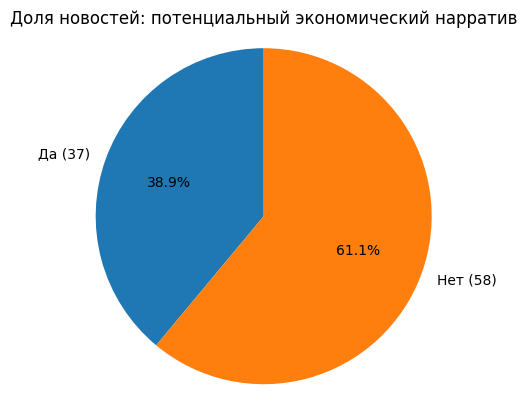

In [39]:
import matplotlib.pyplot as plt

# берём счётчики и упорядочим "Да" / "Нет"
counts = (
    df["is_narrative"]
    .value_counts(dropna=False)
    .reindex(["Да", "Нет"])
    .fillna(0)
    .astype(int)
)

plt.figure()
plt.pie(
    counts.values,
    labels=[f"{lbl} ({val})" for lbl, val in counts.items()],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Доля новостей: потенциальный экономический нарратив")
plt.axis("equal")  # круг не сплющен
plt.show()


In [42]:
import re
import pandas as pd

# словарь маркеров под каждый критерий (по reasoning; можно дополнять)
criteria = {
    "trigger": [
        "обвал","внезапн","скачок","резкое","введение","запрет","санкц","дефицит","рост","паден","шок","кризис"
    ],
    "causal": [
        "привод","влеч","следств","из-за","в результате","цепоч","логич","поэтому","так как","ведет к"
    ],
    "anxiety": [
        "паник","ажиотаж","страх","тревог","неопредел","срочн","угроза","обостр"
    ],
    "state": [
        "цб","центробанк","правительств","министер","регулятор","закон","указ","постанов","ставк","налог","тариф"
    ],
    "media": [
        "эксперт","аналитик","блогер","политик","сми","соцсет","опрос","комментир","заявил","сообщил"
    ],
    "simplelogic": [
        "в итоге","значит","следует","неизбежн","простая","упрощен","все будут"
    ],
    "snowball": [
        "усугуб","новые волны","дальнейш","ожидается","продолжит","эскалац","может вызвать","спровоцир"
    ],
}

def has_any(text: str, needles):
    t = str(text).lower()
    return int(any(n in t for n in needles))

# создаём бинарные столбцы по каждому критерию из reasoning
for key, words in criteria.items():
    df[f"crit_{key}"] = df["reasoning"].apply(lambda s: has_any(s, words))

# сводка по классам
crit_cols = [c for c in df.columns if c.startswith("crit_")]
summary = (
    df.groupby("is_narrative")[crit_cols]
      .mean()
      .mul(100)  # в проценты
      .round(1)
      .reset_index()
)

summary


,is_narrative,crit_trigger,crit_causal,crit_anxiety,crit_state,crit_media,crit_simplelogic,crit_snowball
0,Да,100.0,100.0,91.9,51.4,100.0,100.0,94.6
1,Нет,100.0,100.0,96.6,32.8,100.0,96.6,69.0


In [ ]:
# посчитаем, сколько критериев "сработало" по reasoning
df["criteria_hits"] = df[[c for c in df.columns if c.startswith("crit_")]].sum(axis=1)

# отберём топ пограничных: метка Нет, но критериев много (например, ≥3)
borderline = (
    df.query('is_narrative == "Нет"')
      .sort_values("criteria_hits", ascending=False)
      .head(15)[["criteria_hits","title","text","reasoning"]]
)

# покороче текст и reasoning для просмотра в ноутбуке
def shorten(x, n=220):
    s = str(x).strip().replace("\n", " ")
    return s if len(s) <= n else s[:n] + "…"

# на всякий случай покажем какие колонки есть
print("df columns:", list(df.columns))

borderline_display = borderline.copy()

vals = []
for _, r in borderline.iterrows():
    # корректно берём по имени колонки
    title = r.get("title", None)
    text  = r.get("text",  None)

    # нормализуем пустоты
    title = None if title is None or not str(title).strip() or str(title).lower() == "nan" else str(title)
    text  = ""   if text  is None or not str(text).strip()  or str(text).lower()  == "nan" else str(text)

    vals.append(shorten(title if title else text))

borderline_display["title_or_text"] = vals
borderline_display = borderline_display[["criteria_hits","title_or_text","reasoning"]]
borderline_display["reasoning"] = borderline_display["reasoning"].apply(lambda s: shorten(s, 400))

display(borderline_display.style.set_caption("Пограничные кейсы: метка = 'Нет', но критериев много"))



# (необязательно) сохранить обе таблицы на отдельные листы в текущий Excel-результат
# замените путь на свой финальный файл, если хотите выгрузить:
# out_path = "/mnt/data/results_2025-09-30_14-09-38.xlsx"
# with pd.ExcelWriter(out_path, mode="a", engine="openpyxl", if_sheet_exists="replace") as w:
#     summary.to_excel(w, sheet_name="criteria_summary", index=False)
#     borderline_display.to_excel(w, sheet_name="borderline_cases", index=False)


df columns: ['id', 'title', 'date', 'text', 'is_narrative', 'reasoning', 'crit_trigger', 'crit_causal', 'crit_anxiety', 'crit_state', 'crit_media', 'crit_simplelogic', 'crit_snowball', 'criteria_hits']


,criteria_hits,title_or_text,reasoning
94,7,"Ключевая ставка Банка России в сентябре может снизиться до 17% годовых, заявил РИА Новости глава комитета ГД по финансовому рынку Анатолий Аксаков в преддверии Восточного экономического форума 🔹 Подписаться на РИА Новос…","1. Триггерное событие: присутствует — заявление о возможном снижении ключевой ставки, но событие не вызывает массовой тревоги, а скорее является плановым прогнозом. 2. Причинно-следственные связи: отсутствуют — текст не объясняет, как снижение ставки повлияет на экономику. 3. Эмоциональная окраска и тревожность: отсутствует — язык нейтральный, без слов страха или срочности. 4. Роль государства и и…"
17,7,"Сбербанк увеличил ставку по СберВкладу на полгода до 23% годовых. В новом предложении максимальная ставка доступна для зарплатных клиентов, с пакетом СберПремьер составит 23% годовых, без него 22,5% годовых. 🤑 The Экон…","1. Триггерное событие: присутствует (увеличение ставки Сбербанком), но событие локальное и не вызывает массовой тревоги. 2. Причинно-следственные связи: отсутствуют — нет объяснений экономических последствий. 3. Эмоциональная окраска: слабая (эмодзи 🤑 передаёт позитив, но не тревогу). 4. Роль государства: не упоминается. 5. Участие СМИ/лидеров: отсутствует (нет ссылок на экспертов или массовое осв…"
34,7,"Центробанк Турции впервые почти за два года снизил учетную ставку на 250 базисных пунктов - с 50% до 47,5%. Об этом говорится в сообщении регулятора по итогам последнего в этом году заседания комитета по монетарной пол…","1. Триггерное событие: присутствует — снижение ставки ЦБ Турции на 250 б.п. с 50% до 47,5%, но событие техническое, без явного потенциала массовой тревоги. 2. Причинно-следственные связи: отсутствуют — текст констатирует факт без объяснения последствий. 3. Эмоциональная окраска и тревожность: отсутствуют — нейтральный язык, нет слов страха или срочности. 4. Роль государства и институтов: присутств…"
72,7,Сбербанк сообщил о снижении ставок по ипотеке и потребкредитам с 10 июня и по вкладам с 11 июня. Максимальная ставка для сберегательных продуктов составит 19% годовых. Сегодня Центробанк впервые за три года понизил ключе…,"1. Триггерное событие: присутствует — снижение ставок Сбербанком и ЦБ, но событие не вызывает массовой тревоги. 2. Причинно-следственные связи: отсутствуют — автор не объясняет связи между событиями. 3. Эмоциональная окраска и тревожность: отсутствует — текст нейтрален, без слов страха или срочности. 4. Роль государства и институтов: присутствует — упоминание ЦБ, но его действия не представлены ка…"
74,7,"#VTBR 🏦 Тезис о сильном покупателе в ВТБ, выкупающем просадки, подтверждается 👁 Покупок в бумаге на 300 млн руб больше, чем продаж, согласно данным Дельты Шпиона РЦБ. Акция корректируется всего на 0.5% при падении инде…","Анализ текста по критериям: 1. Триггерное событие — присутствует (данные о превышении покупок над продажами на 300 млн руб.), но событие локальное и не способно вызвать массовое внимание. 2. Причинно-следственные связи — слабо выражены, автор лишь констатирует корреляцию между покупками и устойчивостью акции без глубокого объяснения. 3. Эмоциональная окраска — нейтральная, используются деловые фор…"
75,7,"Члены комитета по открытым рынкам ФРС США в основном ожидают сохранения ставки на уровне 4,25-4,5%. При этом, ФРС повысила прогноз по безработице в США на ближайшие полтора года до 4,5% и понизила ожидания по росту ВВП,…","Критерии 1 (триггерное событие): присутствует — чёткое событие (ожидания ФРС по ставке), но не вызывает массовой тревоги. Критерии 2 (причинно-следственные связи): отсутствует — автор не объясняет связи между явлениями, только перечисляет факты. Критерии 3 (эмоциональная окраска): отсутствует — язык нейтральный, нет слов тревоги или срочности. Критерии 4 (роль государства): присутствует — упоминае…"
28,7,#AGRO Русагро в этом году планирует поставить в Китай 10 тыс. т свинины — Интерфакс Первые партии этого мяса в Китай компания отправила в июне. Премия китайского рынка 

,criteria_hits,title_or_text,reasoning
94,7,Ключевая ставка Банка России в сентябре может ...,1. Триггерное событие: присутствует — заявлени...
17,7,Сбербанк увеличил ставку по СберВкладу на полг...,1. Триггерное событие: присутствует (увеличени...
34,7,Центробанк Турции впервые почти за два года сн...,1. Триггерное событие: присутствует — снижение...
72,7,Сбербанк сообщил о снижении ставок по ипотеке ...,1. Триггерное событие: присутствует — снижение...
74,7,"#VTBR 🏦 Тезис о сильном покупателе в ВТБ, выку...",Анализ текста по критериям: 1. Триггерное собы...
75,7,Члены комитета по открытым рынкам ФРС США в ос...,Критерии 1 (триггерное событие): присутствует ...
28,7,#AGRO Русагро в этом году планирует поставить ...,1. Триггерное событие: присутствует — планы по...
25,7,С 1 января в России повысят пенсии как работаю...,1. Триггерное событие: присутствует — чёткое у...
80,7,"Цена нового импортного автомобиля, привезенног...",1. Триггерное событие: присутствует слабо — уп...
27,7,#DBLB ❗️ Как вернуть до 50% от инвестиций Уча...,Анализ по критериям: 1) Триггерное событие — е...


In [48]:
df.to_excel('новости_с_критериями.xlsx', index=False)